# Полный цикл обработки данных. От нормализации данных до расчётов, визуализаций и интерпретации результатов.

- Автор: Бышин М.И. (hh.ru/resume/3a27e4d7ff0ef40ab90039ed1f6f445a567078)

**Комментарий:**
- Дал себе волю по-макисмуму изучить данные. В связи с чем, делал большое кол-во проверок. Кода получилось много. Большую часть решил оставить в тетради для понимания логики рассуждения.

#### Задание
- В архиве во вложении данные по выдачам кредитов и платежам: плановым и фактическим. Данные актуальны на 08.12.2022. Проанализируйте характер поведения клиентов с точки зрения просрочки: какая динамика просрочки, наблюдается ли рост или снижение?

- Несостыковки в данных можно трактовать на свое усмотрение и отразить в отчете.

#### Описание данных:
- order_id – номер заявки
- created_at - дата создания заявки
- put_at - дата выдачи
- closed_at - дата закрытия
- issued_sum - сумма выдачи
- plan_at - дата планового платежа
- plan_sum_total - сумма планового платежа (накопленным итогом)
- paid_at - дата фактического платежа
- paid_sum - сумма фактического платежа

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Выгружаем данные
orders = pd.read_csv('C:/Users/Max Man/Downloads/orders.csv')
payments = pd.read_csv('C:/Users/Max Man/Downloads/payments.csv')
plan = pd.read_csv('C:/Users/Max Man/Downloads/plan.csv')

### 1. Подготовка данных

#### Знакомство с данными

In [3]:
# Знакомимся
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55748 entries, 0 to 55747
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    55748 non-null  int64  
 1   created_at  55748 non-null  object 
 2   put_at      55748 non-null  object 
 3   closed_at   46472 non-null  object 
 4   issued_sum  55748 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.1+ MB


In [4]:
# Визуальный осмотр
display(orders)

,order_id,created_at,put_at,closed_at,issued_sum
0,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0
1,400005838,2022-06-02 00:10:22.997,2022-06-02 15:41:33.267,2022-06-02 17:38:43.917,20000.0
2,400007915,2022-06-02 00:18:04.000,2022-06-05 19:17:38.547,2022-06-21 21:55:51.877,5820.0
3,400008952,2022-06-02 00:22:07.000,2022-06-03 14:25:18.033,2022-07-12 10:47:46.307,9000.0
4,400009027,2022-06-02 00:25:39.000,2022-06-02 00:40:40.320,2022-06-22 14:15:07.423,5000.0
...,...,...,...,...,...
55743,495174013,2022-08-31 23:29:32.000,2022-09-01 00:07:26.307,NaN,9500.0
55744,495174505,2022-08-31 23:41:57.997,2022-09-05 17:51:19.003,2022-09-16 18:36:09.857,14930.0
55745,495175322,2022-08-31 23:46:04.997,2022-09-01 00:03:52.010,2022-09-09 21:08:18.970,4000.0
55746,495176080,2022-08-31 23:47:20.997,2022-08-31 23:49:03.027,2022-09-12 00:58:57.037,5000.0


**Промежуточные выводы:**
- Типы данных в столбцах `created_at`, `put_at`, `closed_at` меняем на `datetime`.
- Пропуски содержатся в столбцах: `closed_at`. Критичность этого параметра определим позже.
- Проверка на уникальные значения и дубликаты позже.

In [5]:
# Знакомимся
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143284 entries, 0 to 143283
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   order_id  143284 non-null  int64  
 1   paid_at   143284 non-null  object 
 2   paid_sum  143284 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.3+ MB


In [6]:
# Визуальный осмотр
display(payments)

,order_id,paid_at,paid_sum
0,400013633,2022-06-02 00:48:13.800,2500.00
1,400018480,2022-06-02 01:52:05.707,1070.00
2,400032001,2022-06-02 04:55:40.307,4200.00
3,400033195,2022-06-02 05:44:23.480,2850.00
4,400039407,2022-06-02 06:53:54.503,10100.00
...,...,...,...
143279,469255350,2022-12-08 12:57:23.747,343.99
143280,452985418,2022-12-08 12:59:40.997,984.83
143281,490824962,2022-12-08 13:09:21.673,866.04
143282,480026135,2022-12-08 13:25:11.987,1193.25


**Промежуточные выводы:**
- Тип данных в столбце `paid_at` меняем на `datetime`.
- Проверка на уникальные значения и дубликаты позже.
- Поле `order_id` является ключём.

In [7]:
# Знакомимся
plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420282 entries, 0 to 420281
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        420282 non-null  int64  
 1   plan_at         420282 non-null  object 
 2   plan_sum_total  420282 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 9.6+ MB


In [8]:
# Визуальный осмотр
display(plan)

,order_id,plan_at,plan_sum_total
0,400001732,2022-06-02,5600.00
1,400001732,2022-07-02,9450.00
2,400001732,2022-08-01,12170.00
3,400001732,2022-08-31,14890.00
4,400001732,2022-09-30,17610.00
...,...,...,...
420277,495177509,2022-12-22,34248.70
420278,495177509,2023-01-06,36863.04
420279,495177509,2023-01-21,39440.38
420280,495177509,2023-02-05,41980.73


**Промежуточные выводы:**
- Тип данных в столбце `plan_at` меняем на `datetime`.
- Проверка на уникальные/аномальные значения и дубликаты позже.
- Поле `order_id` является ключём.

#### Предобработка датасета orders

**Изменение форматов:**

In [9]:
# Преобразуем столбцы в формат datetime
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['put_at'] = pd.to_datetime(orders['put_at'])
orders['closed_at'] = pd.to_datetime(orders['closed_at'], errors='coerce')

# Проверим результат
print("Типы данных после преобразования:")
print(orders.dtypes)

Типы данных после преобразования:
order_id               int64
created_at    datetime64[ns]
put_at        datetime64[ns]
closed_at     datetime64[ns]
issued_sum           float64
dtype: object


In [10]:
# Визуальный осмотр
display(orders)

,order_id,created_at,put_at,closed_at,issued_sum
0,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0
1,400005838,2022-06-02 00:10:22.997,2022-06-02 15:41:33.267,2022-06-02 17:38:43.917,20000.0
2,400007915,2022-06-02 00:18:04.000,2022-06-05 19:17:38.547,2022-06-21 21:55:51.877,5820.0
3,400008952,2022-06-02 00:22:07.000,2022-06-03 14:25:18.033,2022-07-12 10:47:46.307,9000.0
4,400009027,2022-06-02 00:25:39.000,2022-06-02 00:40:40.320,2022-06-22 14:15:07.423,5000.0
...,...,...,...,...,...
55743,495174013,2022-08-31 23:29:32.000,2022-09-01 00:07:26.307,NaT,9500.0
55744,495174505,2022-08-31 23:41:57.997,2022-09-05 17:51:19.003,2022-09-16 18:36:09.857,14930.0
55745,495175322,2022-08-31 23:46:04.997,2022-09-01 00:03:52.010,2022-09-09 21:08:18.970,4000.0
55746,495176080,2022-08-31 23:47:20.997,2022-08-31 23:49:03.027,2022-09-12 00:58:57.037,5000.0


**Изучим ситуацию с пропусками:**

In [11]:
# Выводим все строки с пропусками и считаем их кол-во
na_closed_at = orders[orders['closed_at'].isna()]
print(f"Всего строк с пропусками в closed_at: {len(na_closed_at)}")

# Вычисляем процентное соотношение строк с пропусками
perc_na = round(len(na_closed_at) / len(orders['closed_at']) * 100, 2)
print(f"Процентное соотношение строк с пропусками: {perc_na}%")

Всего строк с пропусками в closed_at: 9276
Процентное соотношение строк с пропусками: 16.64%


In [12]:
# Визуально осмотрим
display(na_closed_at)

,order_id,created_at,put_at,closed_at,issued_sum
31,400039450,2022-06-02 06:06:20.000,2022-06-02 17:04:46.147,NaT,8140.0
53,400087077,2022-06-02 06:49:06.997,2022-06-02 06:50:21.053,NaT,2920.0
62,400104071,2022-06-02 07:24:24.000,2022-06-02 07:40:44.230,NaT,1720.0
67,400114009,2022-06-02 07:46:38.000,2022-06-02 07:54:54.360,NaT,13600.0
80,400128637,2022-06-02 08:37:15.000,2022-06-02 08:56:56.887,NaT,8500.0
...,...,...,...,...,...
55721,495129029,2022-08-31 22:40:19.997,2022-09-01 11:15:29.283,NaT,8500.0
55724,495142096,2022-08-31 22:44:29.997,2022-09-07 15:41:11.330,NaT,2720.0
55732,495148390,2022-08-31 23:17:10.000,2022-09-02 11:15:32.773,NaT,3450.0
55743,495174013,2022-08-31 23:29:32.000,2022-09-01 00:07:26.307,NaT,9500.0


- Очень похоже на то, что пропуски в этом поле несут в себе информацию о том, что заявка еще не закрыта. То есть, кредит выдан, но не возвращён. 

**Изучим ситуацию с аномальными значениями в данных:**

In [13]:
# Проверим наличие аномальных значений для столбцов с числами и датами
columns_check = ['created_at', 'put_at', 'closed_at', 'issued_sum']

# Напишем функцию
for col in columns_check:
    if col in orders.columns:
        print(f"{col}: min = {orders[col].min()}, max = {orders[col].max()}")
    else:
        print(f"Столбец {col} не найден")

created_at: min = 2022-06-02 00:00:23.997000, max = 2022-08-31 23:49:42.997000
put_at: min = 2022-06-02 00:40:40.320000, max = 2022-09-29 18:46:58.387000
closed_at: min = 2022-06-02 06:53:54.503000, max = 2022-12-08 09:48:38.233000
issued_sum: min = 1000.0, max = 28570.0


- Аномальных значений не наблюдается.

**Проверим уникальность значений:**

In [14]:
# Смотрим
unique = orders['order_id'].nunique()
print(f"Столбец order_id содержит {unique} строк")

Столбец order_id содержит 55748 строк


- Повторяющихся order_id в датасете - нет.

**Проверим наличие дубликатов(на всякий случай):**

In [15]:
# Смотрим
dup = orders.duplicated().sum()
print(f"Датафрейм содержит {dup} дубликатов")

Датафрейм содержит 0 дубликатов


**Датасет `orders` готов для дальнейшего анализа.**

#### Предобработка датасета payments

In [16]:
# Преобразуем столбцы в формат datetime
payments['paid_at'] = pd.to_datetime(payments['paid_at'])

# Проверим результат
print("Типы данных после преобразования:")
print(payments.dtypes)

Типы данных после преобразования:
order_id             int64
paid_at     datetime64[ns]
paid_sum           float64
dtype: object


**Изучим ситуацию с аномальными значениями в данных:**

In [17]:
# Проверим наличие аномальных значений для столбцов с числами и датами
columns_check = ['paid_at', 'paid_sum']

# Напишем функцию
for col in columns_check:
    if col in payments.columns:
        print(f"{col}: min = {payments[col].min()}, max = {payments[col].max()}")
    else:
        print(f"Столбец {col} не найден")

paid_at: min = 2022-06-02 00:48:13.800000, max = 2022-12-08 13:28:23.703000
paid_sum: min = 0.02, max = 49469.37


- Аномальных значений не наблюдается. Две копейки, тоже деньги)

**Проверим уникальность значений:**

In [18]:
# Смотрим
unique = payments['order_id'].nunique()
print(f"Столбец order_id содержит {unique} строк")

Столбец order_id содержит 53730 строк


- Делаем вывод о том, что один `order_id` может несуолько раз встречаться в датасете.

**Проверим наличие дубликатов:**

In [19]:
# Смотрим
dup = payments.duplicated().sum()
print(f"Датафрейм содержит {dup} дубликатов")

Датафрейм содержит 5 дубликатов


In [20]:
# Визуально осмотрим
duplicates = payments[payments.duplicated(keep=False)]  #показываем все дубликаты
display(duplicates)

,order_id,paid_at,paid_sum
11474,411504997,2022-06-24 17:14:56.997,10100.0
11475,411504997,2022-06-24 17:14:56.997,10100.0
12469,422632789,2022-06-25 23:16:16.000,8080.0
12470,422632789,2022-06-25 23:16:16.000,8080.0
37758,432761640,2022-07-21 12:38:12.000,150.0
37759,432761640,2022-07-21 12:38:12.000,150.0
38413,420036980,2022-07-21 20:08:58.997,4800.0
38414,420036980,2022-07-21 20:08:58.997,4800.0
139589,456075017,2022-11-22 19:44:08.793,2720.0
139590,456075017,2022-11-22 19:44:08.793,2720.0


- Значения являются полными дубликатами. Их стоит удалить.

In [21]:
# Удаляем
payments = payments.drop_duplicates()

# Проверяем
payments.duplicated().sum()

np.int64(0)

**Датасет `payments` готов для дальнейшего анализа.**

#### Предобработка датасета plan

In [22]:
# Преобразуем столбцы в формат datetime
plan['plan_at'] = pd.to_datetime(plan['plan_at'])

# Проверим результат
print("Типы данных после преобразования:")
print(plan.dtypes)

Типы данных после преобразования:
order_id                   int64
plan_at           datetime64[ns]
plan_sum_total           float64
dtype: object


**Изучим ситуацию с аномальными значениями в данных:**

In [23]:
# Проверим наличие аномальных значений для столбцов с числами и датами
columns_check = ['plan_at', 'plan_sum_total']

# Напишем функцию
for col in columns_check:
    if col in plan.columns:
        print(f"{col}: min = {plan[col].min()}, max = {plan[col].max()}")
    else:
        print(f"Столбец {col} не найден")

plan_at: min = 2022-06-02 00:00:00, max = 2023-06-11 00:00:00
plan_sum_total: min = 0.0, max = 2300000.0


- Сложно сказать, может-ли быть сумма планового платежа (накопленным итогом) равной нулю. Посчитаем количество этих значений.

In [24]:
# Подсчитываем количество строк
zero_count = (plan['plan_sum_total'] == 0).sum()
# Смотрим
print(f"Количество строк с 'plan_sum_total' равным 0: {zero_count}")

# Вычисляем процентное соотношение строк
perc = round(zero_count / len(plan) * 100, 2)
print(f"Процентное соотношение строк с пропусками: {perc}%")

Количество строк с 'plan_sum_total' равным 0: 353
Процентное соотношение строк с пропусками: 0.08%


- Процентное соотношение небольшое, сильно не повлияет на результаты исследования. Возможно, буду фильтровать.
- Требуются пояснения.

**Проверим уникальность значений:**

In [25]:
# Смотрим
unique = plan['order_id'].nunique()
print(f"Столбец order_id содержит {unique} строк")

Столбец order_id содержит 55748 строк


- Количество уникальных значений поля `order_id` соотвествует количеству уникальных значений поля `order_id` в датасете `orders`.

**Проверим наличие дубликатов:**

In [26]:
# Смотрим
dup = plan.duplicated().sum()
print(f"Датафрейм содержит {dup} дубликатов")

Датафрейм содержит 0 дубликатов


**Датасет `plan` готов для дальнейшего анализа.**

#### Объединим данные в единый датафрейм

In [27]:
# Создаем копии чтобы избежать предупреждений
orders_copy = orders.copy()
payments_copy = payments.copy()
plan_copy = plan.copy()

In [28]:
# Сначала найдем для каждого платежа факт оплаты
plan_with_payments = plan_copy.merge(
    payments_copy.groupby('order_id').agg({
        'paid_at': 'min',
        'paid_sum': 'sum'
    }).reset_index(),
    on='order_id',
    how='left'
)

In [29]:
# Смотрим
plan_with_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420282 entries, 0 to 420281
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        420282 non-null  int64         
 1   plan_at         420282 non-null  datetime64[ns]
 2   plan_sum_total  420282 non-null  float64       
 3   paid_at         402910 non-null  datetime64[ns]
 4   paid_sum        402910 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 16.0 MB


In [30]:
# Добавим информацию о займе
plan_with_orders = plan_with_payments.merge(
    orders_copy[['order_id', 'created_at', 'issued_sum']],
    on='order_id',
    how='left'
)

In [31]:
# Изучаем получившийся датафрейм
plan_with_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420282 entries, 0 to 420281
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        420282 non-null  int64         
 1   plan_at         420282 non-null  datetime64[ns]
 2   plan_sum_total  420282 non-null  float64       
 3   paid_at         402910 non-null  datetime64[ns]
 4   paid_sum        402910 non-null  float64       
 5   created_at      420282 non-null  datetime64[ns]
 6   issued_sum      420282 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1)
memory usage: 22.4 MB


In [32]:
# Визуально смотрим
display(plan_with_orders)

,order_id,plan_at,plan_sum_total,paid_at,paid_sum,created_at,issued_sum
0,400001732,2022-06-02,5600.00,2022-06-02 20:20:16.790,23050.00,2022-06-02 00:00:23.997,13600.0
1,400001732,2022-07-02,9450.00,2022-06-02 20:20:16.790,23050.00,2022-06-02 00:00:23.997,13600.0
2,400001732,2022-08-01,12170.00,2022-06-02 20:20:16.790,23050.00,2022-06-02 00:00:23.997,13600.0
3,400001732,2022-08-31,14890.00,2022-06-02 20:20:16.790,23050.00,2022-06-02 00:00:23.997,13600.0
4,400001732,2022-09-30,17610.00,2022-06-02 20:20:16.790,23050.00,2022-06-02 00:00:23.997,13600.0
...,...,...,...,...,...,...,...
420277,495177509,2022-12-22,34248.70,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420278,495177509,2023-01-06,36863.04,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420279,495177509,2023-01-21,39440.38,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420280,495177509,2023-02-05,41980.73,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0


- У нас появились пропуски в объединённом датафрейме. Изучим причину.

In [33]:
# Выводим все строки с пропусками и считаем их кол-во
na_paid_at = plan_with_orders[plan_with_orders['paid_sum'].isna()]
print(f"Всего строк с пропусками в closed_at: {len(na_paid_at)}")

# Вычисляем процентное соотношение строк с пропусками
na_perc = round(len(na_paid_at) / len(plan_with_orders['paid_sum']) * 100, 2)
print(f"Процентное соотношение строк с пропусками: {na_perc}%")

Всего строк с пропусками в closed_at: 17372
Процентное соотношение строк с пропусками: 4.13%


In [34]:
# Визуально осмотрим
display(na_paid_at)

,order_id,plan_at,plan_sum_total,paid_at,paid_sum,created_at,issued_sum
407,400087077,2022-06-02,920.00,NaT,NaN,2022-06-02 06:49:06.997,2920.0
408,400087077,2022-06-17,1380.00,NaT,NaN,2022-06-02 06:49:06.997,2920.0
409,400087077,2022-07-02,2112.51,NaT,NaN,2022-06-02 06:49:06.997,2920.0
410,400087077,2022-07-17,2720.41,NaT,NaN,2022-06-02 06:49:06.997,2920.0
411,400087077,2022-08-01,3147.70,NaT,NaN,2022-06-02 06:49:06.997,2920.0
...,...,...,...,...,...,...,...
420089,495129029,2022-10-31,7671.20,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420090,495129029,2022-11-30,9381.40,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420091,495129029,2022-12-30,11081.40,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420092,495129029,2023-01-29,12781.40,NaT,NaN,2022-08-31 22:40:19.997,8500.0


In [35]:
# Визуально осмотрим
group = na_paid_at['order_id'].nunique()
print(f"Итого уникальных 'order_id' с пропусками: {group}")

Итого уникальных 'order_id' с пропусками: 2018


- Выберем несколько рандомных `order_id`, чтобы понять причину пропусков.

In [36]:
order_id_400087077 = na_paid_at[na_paid_at['order_id'] == 400087077]
print(f"Всего строк с order_id = 400087077: {len(order_id_400087077)}")
display(order_id_400087077)

Всего строк с order_id = 400087077: 13


,order_id,plan_at,plan_sum_total,paid_at,paid_sum,created_at,issued_sum
407,400087077,2022-06-02,920.00,NaT,NaN,2022-06-02 06:49:06.997,2920.0
408,400087077,2022-06-17,1380.00,NaT,NaN,2022-06-02 06:49:06.997,2920.0
409,400087077,2022-07-02,2112.51,NaT,NaN,2022-06-02 06:49:06.997,2920.0
410,400087077,2022-07-17,2720.41,NaT,NaN,2022-06-02 06:49:06.997,2920.0
411,400087077,2022-08-01,3147.70,NaT,NaN,2022-06-02 06:49:06.997,2920.0
412,400087077,2022-08-16,3556.37,NaT,NaN,2022-06-02 06:49:06.997,2920.0
413,400087077,2022-08-31,3890.43,NaT,NaN,2022-06-02 06:49:06.997,2920.0
414,400087077,2022-09-15,4213.39,NaT,NaN,2022-06-02 06:49:06.997,2920.0
415,400087077,2022-09-30,4526.21,NaT,NaN,2022-06-02 06:49:06.997,2920.0
416,400087077,2022-10-15,4828.90,NaT,NaN,2022-06-02 06:49:06.997,2920.0


In [37]:
order_id_495129029 = na_paid_at[na_paid_at['order_id'] == 495129029]
print(f"Всего строк с order_id = 495129029: {len(order_id_495129029)}")
display(order_id_495129029)

Всего строк с order_id = 495129029: 7


,order_id,plan_at,plan_sum_total,paid_at,paid_sum,created_at,issued_sum
420087,495129029,2022-09-01,3500.0,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420088,495129029,2022-10-01,5910.0,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420089,495129029,2022-10-31,7671.2,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420090,495129029,2022-11-30,9381.4,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420091,495129029,2022-12-30,11081.4,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420092,495129029,2023-01-29,12781.4,NaT,NaN,2022-08-31 22:40:19.997,8500.0
420093,495129029,2023-02-28,14481.4,NaT,NaN,2022-08-31 22:40:19.997,8500.0


- Теперь выберем несколько рандомных "нормальных" `order_id`, которые не содержат пропуски в строках и сравним их, чтобы причину пропусков.

In [38]:
order_id_400001732 = plan_with_orders[plan_with_orders['order_id'] == 400001732]
print(f"Всего строк с order_id = 400001732: {len(order_id_400001732)}")
display(order_id_400001732)

Всего строк с order_id = 400001732: 7


,order_id,plan_at,plan_sum_total,paid_at,paid_sum,created_at,issued_sum
0,400001732,2022-06-02,5600.0,2022-06-02 20:20:16.790,23050.0,2022-06-02 00:00:23.997,13600.0
1,400001732,2022-07-02,9450.0,2022-06-02 20:20:16.790,23050.0,2022-06-02 00:00:23.997,13600.0
2,400001732,2022-08-01,12170.0,2022-06-02 20:20:16.790,23050.0,2022-06-02 00:00:23.997,13600.0
3,400001732,2022-08-31,14890.0,2022-06-02 20:20:16.790,23050.0,2022-06-02 00:00:23.997,13600.0
4,400001732,2022-09-30,17610.0,2022-06-02 20:20:16.790,23050.0,2022-06-02 00:00:23.997,13600.0
5,400001732,2022-10-30,20330.0,2022-06-02 20:20:16.790,23050.0,2022-06-02 00:00:23.997,13600.0
6,400001732,2022-11-29,23050.0,2022-06-02 20:20:16.790,23050.0,2022-06-02 00:00:23.997,13600.0


In [39]:
order_id_495177509 = plan_with_orders[plan_with_orders['order_id'] == 495177509]
print(f"Всего строк с order_id = 495177509: {len(order_id_495177509)}")
display(order_id_495177509)

Всего строк с order_id = 495177509: 13


,order_id,plan_at,plan_sum_total,paid_at,paid_sum,created_at,issued_sum
420269,495177509,2022-09-01,7130.00,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420270,495177509,2022-09-08,10695.00,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420271,495177509,2022-09-23,16010.00,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420272,495177509,2022-10-08,19956.17,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420273,495177509,2022-10-23,23421.40,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420274,495177509,2022-11-07,26183.72,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420275,495177509,2022-11-22,28909.04,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420276,495177509,2022-12-07,31597.37,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420277,495177509,2022-12-22,34248.70,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0
420278,495177509,2023-01-06,36863.04,2022-09-01 05:50:28.110,36863.04,2022-08-31 23:49:42.997,27130.0


- Исходя из сравнения с "нормальными" данными(без пропусков), скорее всего эти данные о просрочке платежей. Поэтому, сейчас никаким образом эти пропуски не будем обрабатывать. Но учтём их при дальнейшем анализе.
- Требуются пояснения.

**Датасет `plan_with_orders` готов для дальнейшего анализа.**

### 2. Аналитическая часть

#### Анализ динамики просрочки по месяцам

In [40]:
# Создаем булеву переменную, указывающую был ли платеж просрочен
plan_with_orders['is_delayed'] = plan_with_orders['paid_at'] > plan_with_orders['plan_at']

# Рассчитываем количество дней просрочки (разница между фактической и плановой датой)
plan_with_orders['delay_days'] = (plan_with_orders['paid_at'] - plan_with_orders['plan_at']).dt.days

# Преобразуем отрицательные значения (досрочные платежи) в 0 и оставляем NaN для отсутствующих платежей
plan_with_orders['delay_days'] = plan_with_orders['delay_days'].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)

# Группируем по месяцам для анализа динамики
# Создаем периодическую переменную месяца для анализа временных трендов
plan_with_orders['plan_month'] = plan_with_orders['plan_at'].dt.to_period('M')

# Создаем периодическую переменную месяца создания займа для когортного анализа
plan_with_orders['created_month'] = plan_with_orders['created_at'].dt.to_period('M')

# Группируем данные по месяцам и агрегируем ключевые метрики
monthly_delay_analysis = plan_with_orders.groupby('plan_month', observed=False).agg({
    'order_id': 'count',        # Общее количество платежей в месяце
    'is_delayed': 'sum',        # Количество просроченных платежей
    'delay_days': 'mean'        # Средняя длительность просрочки
}).rename(columns={
    'order_id': 'total_payments',
    'is_delayed': 'delayed_payments', 
    'delay_days': 'avg_delay_days'
})

# Рассчитываем процент просроченных платежей от общего количества
monthly_delay_analysis['delay_rate'] = (monthly_delay_analysis['delayed_payments'] / 
                                       monthly_delay_analysis['total_payments']) * 100

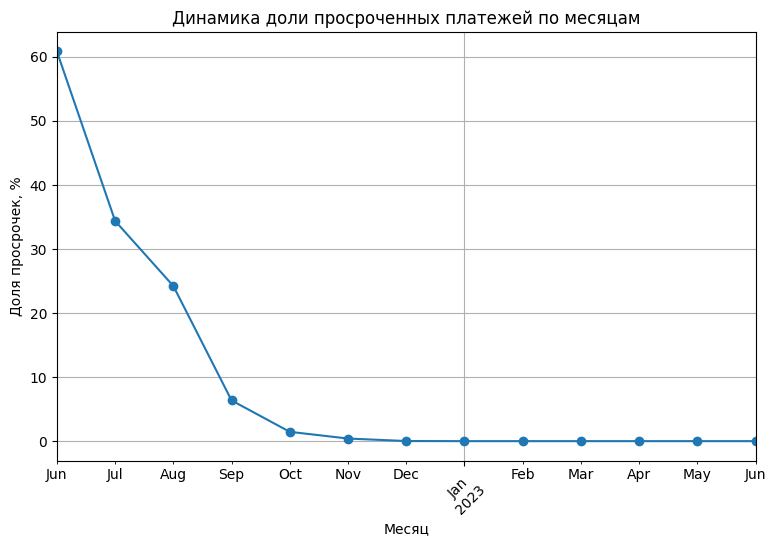

In [41]:
# Визуализация результатов
plt.figure(figsize=(15, 10))

# Динамика доли просроченных платежей
plt.subplot(2, 2, 1)
monthly_delay_analysis['delay_rate'].plot(kind='line', marker='o')  # Линейный график с точками
plt.title('Динамика доли просроченных платежей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Доля просрочек, %')
plt.xticks(rotation=45)  # Наклон подписей для читаемости
plt.grid(True)  # Добавляем сетку

plt.tight_layout()  # Автоматическое выравнивание графиков
plt.show()  # Отображение графиков

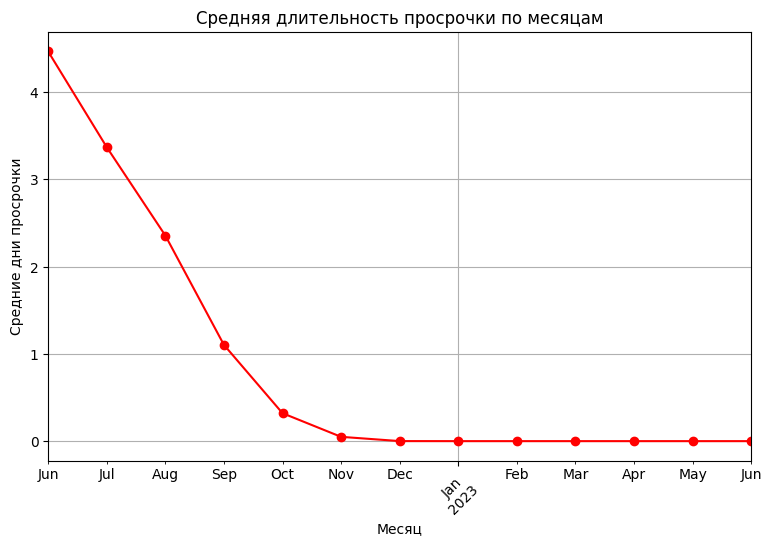

In [42]:
# Визуализация результатов
plt.figure(figsize=(15, 10))

# Средняя длительность просрочки
plt.subplot(2, 2, 2)
monthly_delay_analysis['avg_delay_days'].plot(kind='line', marker='o', color='red')  # Красная линия
plt.title('Средняя длительность просрочки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средние дни просрочки')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()  # Автоматическое выравнивание графиков
plt.show()  # Отображение графиков

In [43]:
# Сезонность
print("\nСезонность просрочки (по месяцам года):")
# Анализ просрочек по месяцам года (вне зависимости от года)
seasonal_analysis = plan_with_orders.groupby(plan_with_orders['plan_at'].dt.month, observed=False).agg({
    'is_delayed': 'mean'  # Средняя доля просрочек по месяцам
}) * 100  # Преобразование в проценты
print(seasonal_analysis.rename(columns={'is_delayed': 'delay_rate_%'}))


Сезонность просрочки (по месяцам года):
         delay_rate_%
plan_at              
1            0.000000
2            0.000000
3            0.000000
4            0.000000
5            0.000000
6           60.783005
7           34.348924
8           24.198646
9            6.346818
10           1.450334
11           0.403365
12           0.016314


#### Анализ по "возрасту" займа (какой по счету платеж)

In [44]:
# Создаем номер платежа для каждого займа (1-й, 2-й, 3-й и т.д.)
plan_with_orders['payment_number'] = plan_with_orders.groupby('order_id').cumcount() + 1

# Анализируем просрочки по порядковому номеру платежа
payment_number_analysis = plan_with_orders.groupby('payment_number', observed=False).agg({
    'order_id': 'count',        # Общее количество платежей с этим номером
    'is_delayed': 'sum',        # Количество просрочек для этого номера платежа
    'delay_days': 'mean'        # Средняя длительность просрочки
}).rename(columns={
    'order_id': 'total_payments',
    'is_delayed': 'delayed_payments',
    'delay_days': 'avg_delay_days'
})

# Рассчитываем процент просрочек для каждого номера платежа
payment_number_analysis['delay_rate'] = (payment_number_analysis['delayed_payments'] / 
                                        payment_number_analysis['total_payments']) * 100

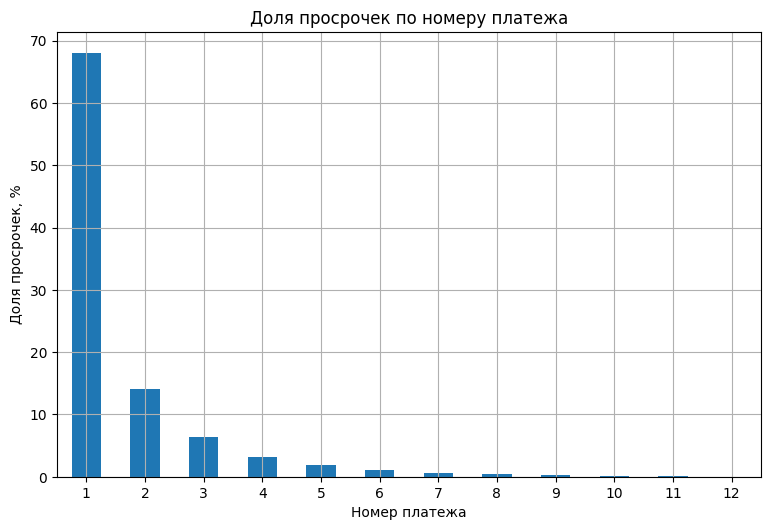

In [45]:
# Визуализация результатов
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 3)
payment_number_analysis.head(12)['delay_rate'].plot(kind='bar')  # Столбчатая диаграмма первых 12 платежей
plt.title('Доля просрочек по номеру платежа')
plt.xlabel('Номер платежа')
plt.ylabel('Доля просрочек, %')
plt.xticks(rotation=0)  # Горизонтальные подписи
plt.grid(True)

plt.tight_layout()  # Автоматическое выравнивание графиков
plt.show()  # Отображение графиков

#### Анализ по сумме займа

In [46]:
# Создаем категории размера займа для анализа зависимости просрочки от суммы
plan_with_orders['loan_size_category'] = pd.cut(plan_with_orders['issued_sum'], 
                                               bins=[0, 5000, 10000, 20000, 50000, float('inf')],
                                               labels=['<5k', '5k-10k', '10k-20k', '20k-50k', '50k+'])

# Анализируем просрочки по категориям размера займа
loan_size_analysis = plan_with_orders.groupby('loan_size_category', observed=True).agg({
    'order_id': 'count',        # Общее количество платежей в категории
    'is_delayed': 'sum',        # Количество просрочек в категории
    'delay_days': 'mean'        # Средняя длительность просрочки
}).rename(columns={
    'order_id': 'total_payments',
    'is_delayed': 'delayed_payments',
    'delay_days': 'avg_delay_days'
})

# Рассчитываем процент просрочек для каждой категории размера займа
loan_size_analysis['delay_rate'] = (loan_size_analysis['delayed_payments'] / 
                                   loan_size_analysis['total_payments']) * 100

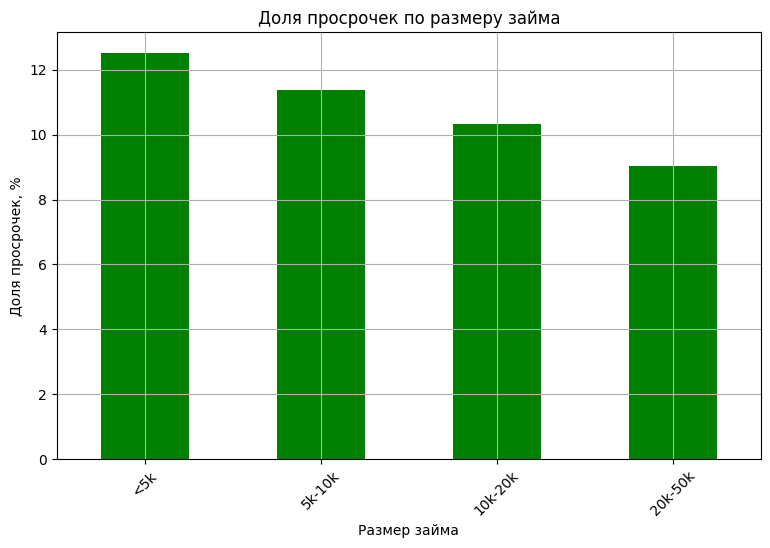

In [47]:
# Визуализация результатов
plt.figure(figsize=(15, 10))

# Просрочка по размеру займа
plt.subplot(2, 2, 4)
loan_size_analysis['delay_rate'].plot(kind='bar', color='green')  # Зеленая столбчатая диаграмма
plt.title('Доля просрочек по размеру займа')
plt.xlabel('Размер займа')
plt.ylabel('Доля просрочек, %')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()  # Автоматическое выравнивание графиков
plt.show()  # Отображение графиков

#### Динамика просрочки по кварталам

In [48]:
# Динамика по кварталам
print("\nДинамика просрочки по кварталам:")
# Создаем квартальную переменную для анализа
plan_with_orders['plan_quarter'] = plan_with_orders['plan_at'].dt.to_period('Q')
# Анализ по кварталам
quarterly_analysis = plan_with_orders.groupby('plan_quarter', observed=False).agg({
    'order_id': 'count',        # Количество платежей в квартале
    'is_delayed': 'mean',       # Доля просроченных платежей
    'delay_days': 'mean'        # Средняя длительность просрочки
}).rename(columns={
    'order_id': 'total_payments',
    'is_delayed': 'delay_rate',
    'delay_days': 'avg_delay_days'
})

quarterly_analysis['delay_rate'] *= 100  # Преобразование в проценты
print(quarterly_analysis[['total_payments', 'delay_rate', 'avg_delay_days']])


Динамика просрочки по кварталам:
              total_payments  delay_rate  avg_delay_days
plan_quarter                                            
2022Q2                 17980   60.789766        4.467763
2022Q3                175927   20.147561        2.149992
2022Q4                178858    0.652473        0.129705
2023Q1                 47507    0.000000        0.000000
2023Q2                    10    0.000000        0.000000


#### Анализ повторных просрочек

In [49]:
# Анализ займов, у которых были просрочки
delayed_orders_analysis = plan_with_orders[plan_with_orders['is_delayed']].groupby('order_id', observed=False).agg({
    'is_delayed': 'count'  # Количество просрочек для каждого займа
}).rename(columns={'is_delayed': 'delayed_payments_count'})

print(f"\nАнализ повторных просрочек:")
print(f"Среднее количество просрочек на один проблемный займ: {delayed_orders_analysis['delayed_payments_count'].mean():.1f}")
print(f"Медианное количество просрочек: {delayed_orders_analysis['delayed_payments_count'].median():.1f}")
print(f"Максимальное количество просрочек у одного займа: {delayed_orders_analysis['delayed_payments_count'].max()}")


Анализ повторных просрочек:
Среднее количество просрочек на один проблемный займ: 1.3
Медианное количество просрочек: 1.0
Максимальное количество просрочек у одного займа: 12


#### Количество order_id с просрочкой

In [50]:
# Подсчет уникальных order_id с хотя бы одной просрочкой
unique_orders_with_delay = plan_with_orders[plan_with_orders['is_delayed']]['order_id'].nunique()
# Общее количество уникальных займов
total_unique_orders = plan_with_orders['order_id'].nunique()

print(f"Уникальных займов с просрочкой: {unique_orders_with_delay:,}")
print(f"Общее количество уникальных займов: {total_unique_orders:,}")
print(f"Доля займов с хотя бы одной просрочкой: {unique_orders_with_delay/total_unique_orders*100:.1f}%")

Уникальных займов с просрочкой: 37,900
Общее количество уникальных займов: 55,748
Доля займов с хотя бы одной просрочкой: 68.0%


#### Вывод обобщённых метрик

In [51]:
# Метрики
print(f"\nОбщая статистика просрочки:")
print(f"Всего плановых платежей: {len(plan_with_orders):,}")  # Форматирование с запятыми
print(f"Просроченных платежей: {plan_with_orders['is_delayed'].sum():,}")
print(f"Общая доля просрочек: {plan_with_orders['is_delayed'].mean()*100:.2f}%")  # Округление до 2 знаков
print(f"Средняя длительность просрочки: {plan_with_orders['delay_days'].mean():.1f} дней")  # Округление до 1 знака


Общая статистика просрочки:
Всего плановых платежей: 420,282
Просроченных платежей: 47,542
Общая доля просрочек: 11.31%
Средняя длительность просрочки: 1.1 дней
